In [1]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [2]:

#Change this line to the directory where inputs are stored

INPUT_FILE= '/home/pbeamer/Documents/h5ad/graphst/V1_Human_Invasive_Ductal_Carcinoma_10xvisium_processed_graphst.h5ad'

#Set fields of anndata where ground truth and embedding for clustering are stored
EMBEDDING = 'X_gst'
GROUND_TRUTH = 'clusters'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = [0.15,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6]
RES_KEYS = ['leiden_'+str(r) for r in RESOLUTIONS]

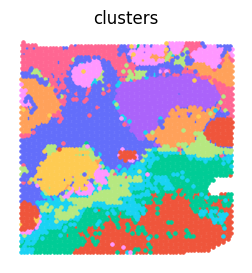

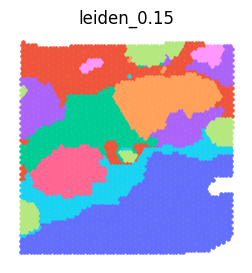

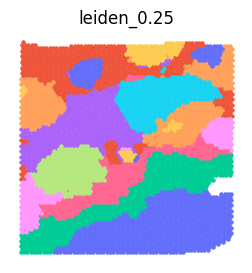

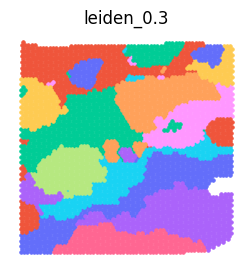

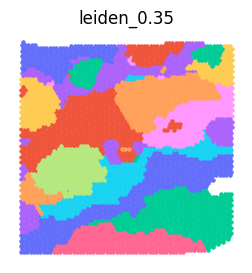

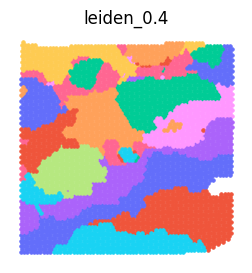

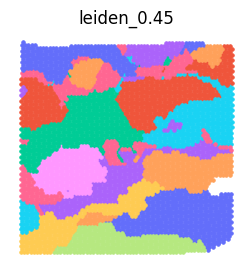

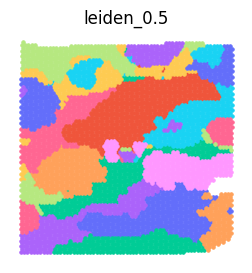

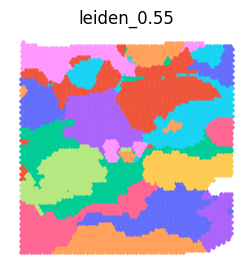

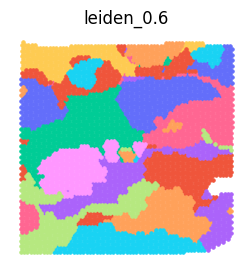

In [3]:

#Preprocess clusterings for each resolution
adata = phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE, reflect=['y'], plots=True,
                            emb=EMBEDDING,resolution=RESOLUTIONS,res_keys=RES_KEYS,ground_truth=GROUND_TRUTH,neighbors=5)

Constructing filtration...


100%|██████████| 8/8 [00:18<00:00,  2.28s/it]


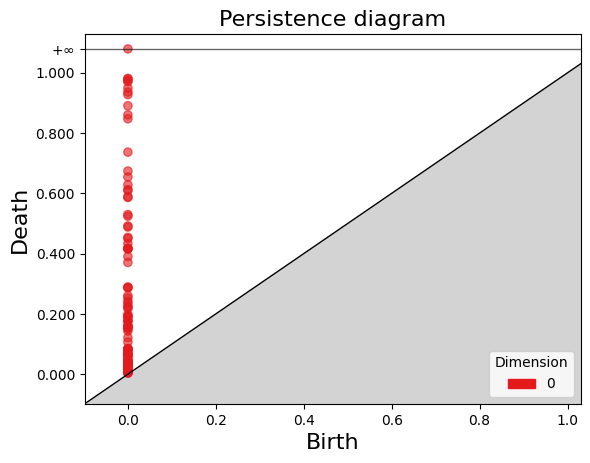

In [4]:
#Build cluster filtration
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='jaccard')
#Plot persistence diagram
from gudhi import plot_persistence_diagram
from gudhi import SimplexTree
plot_persistence_diagram(cluster_complex.persistence());

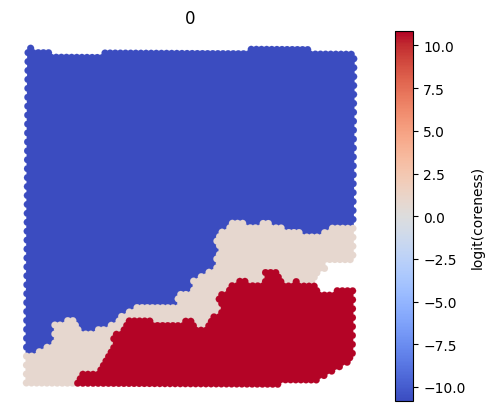

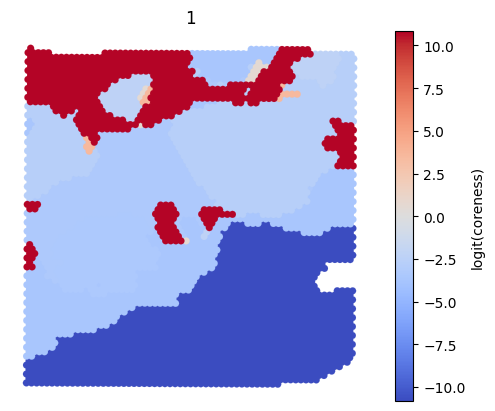

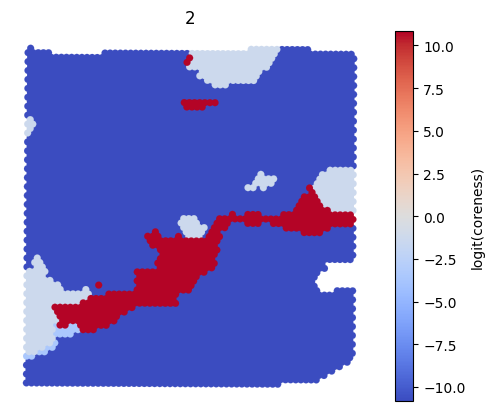

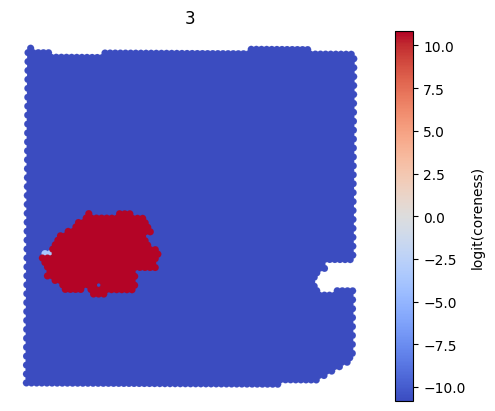

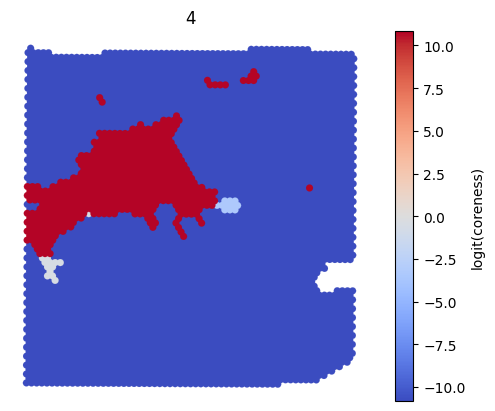

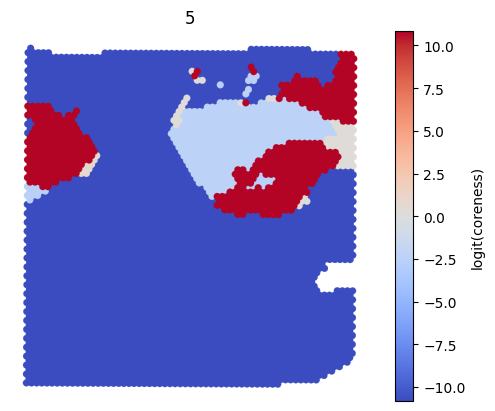

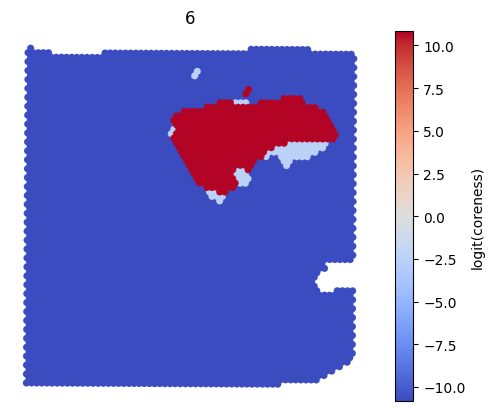

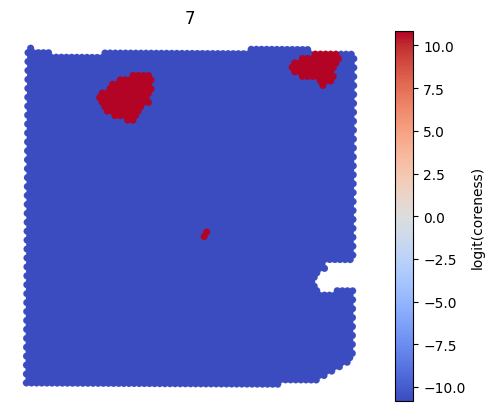

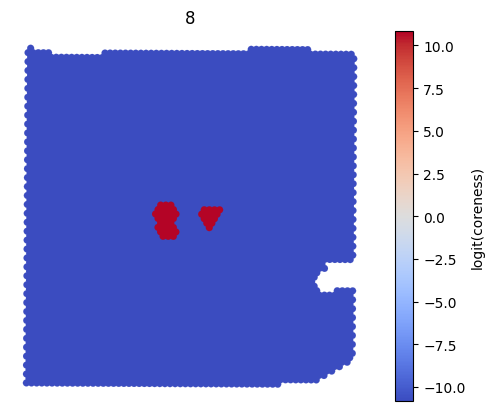

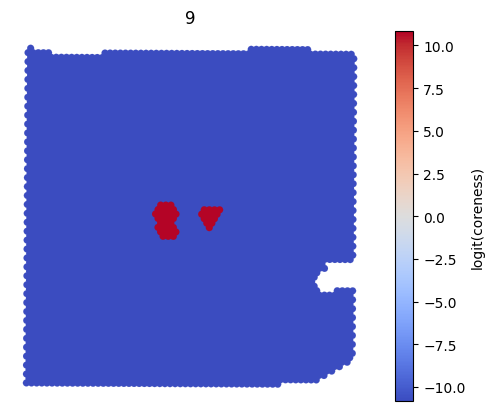

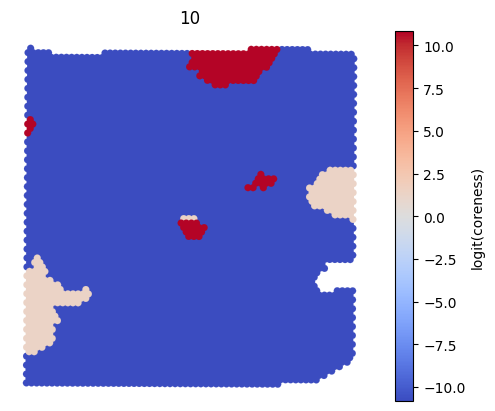

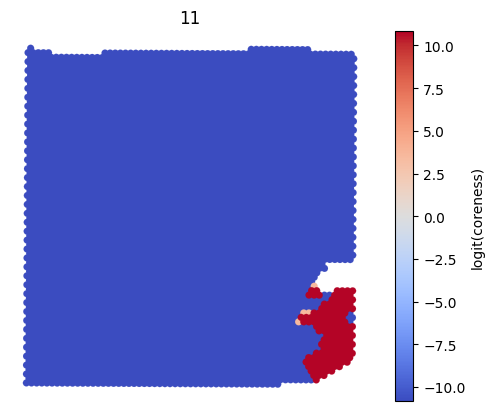

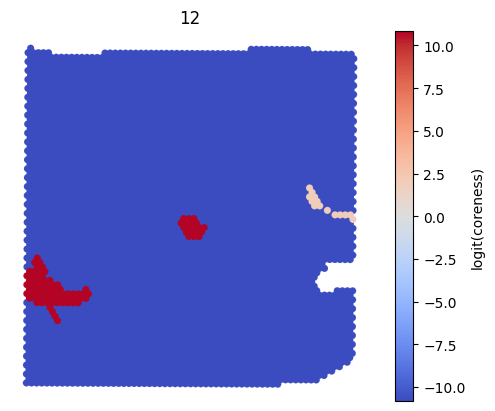

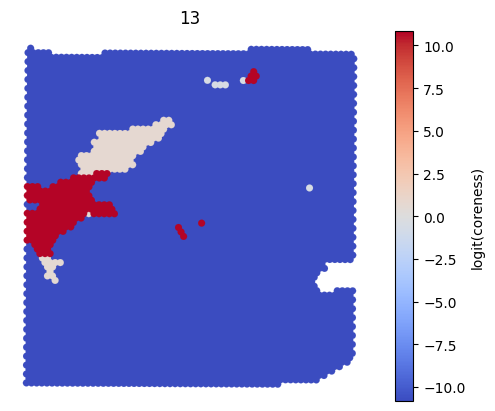

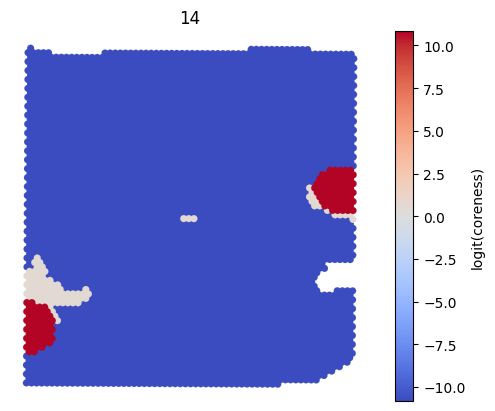

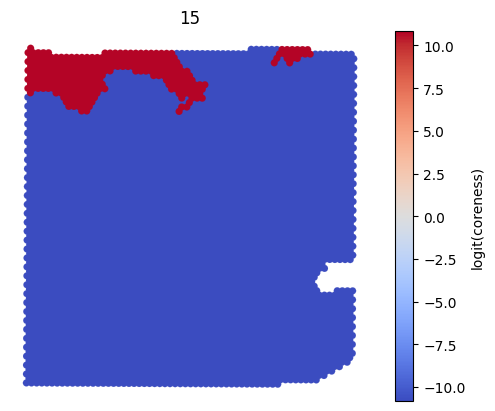

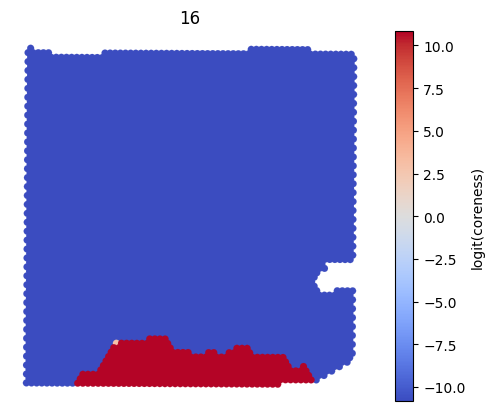

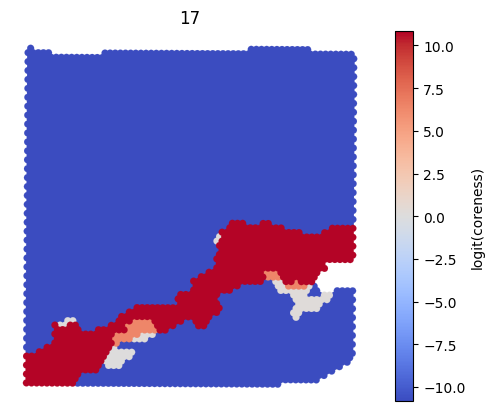

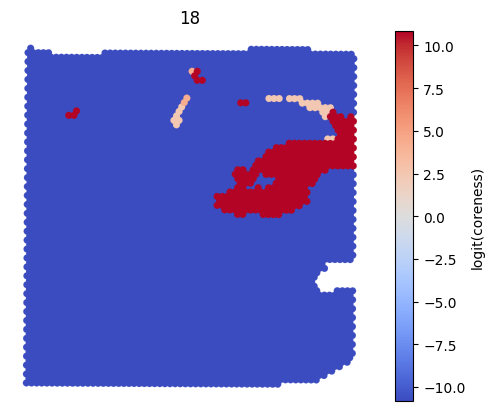

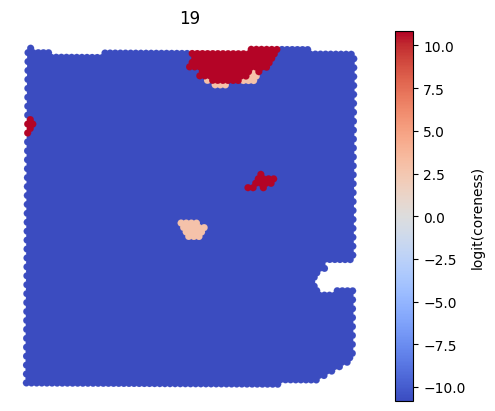

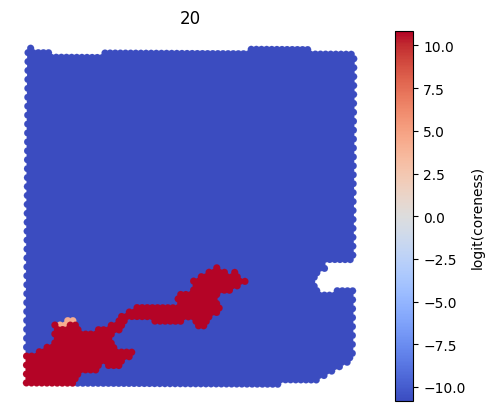

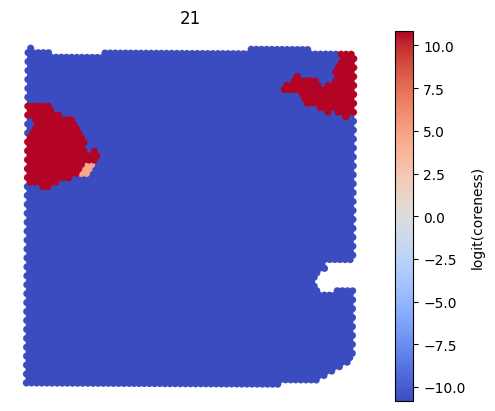

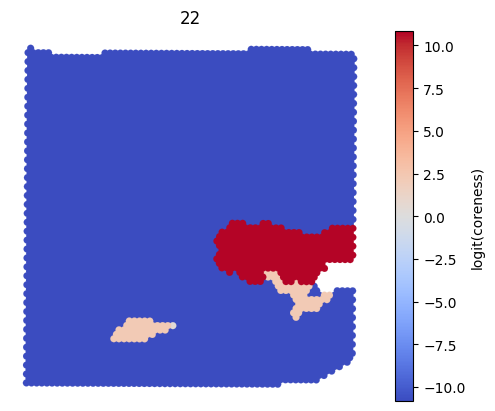

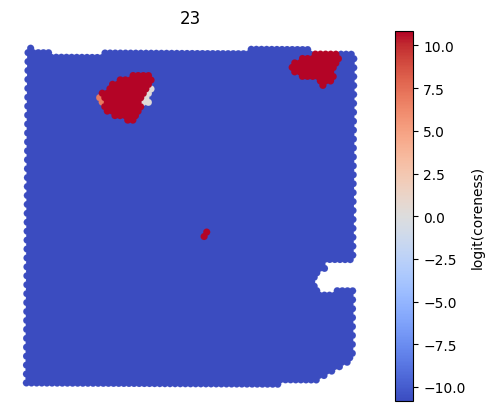

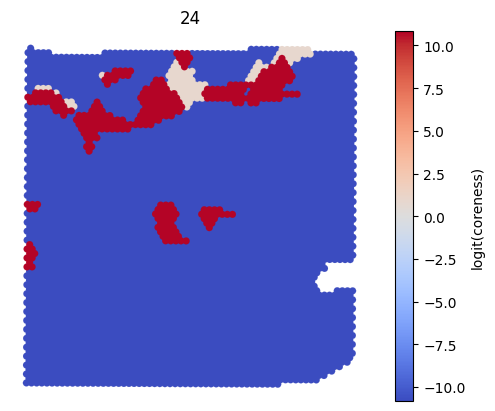

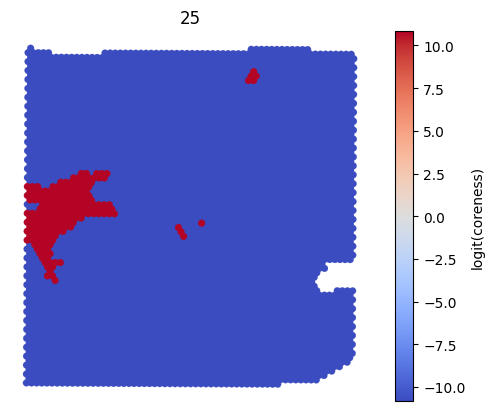

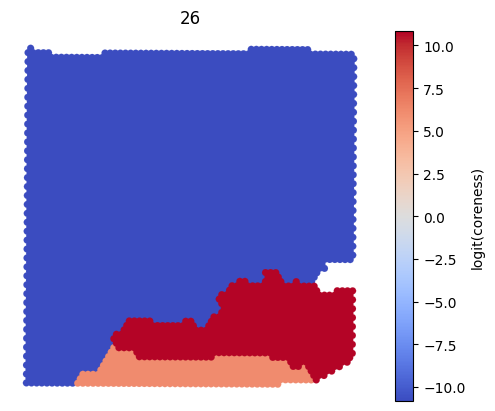

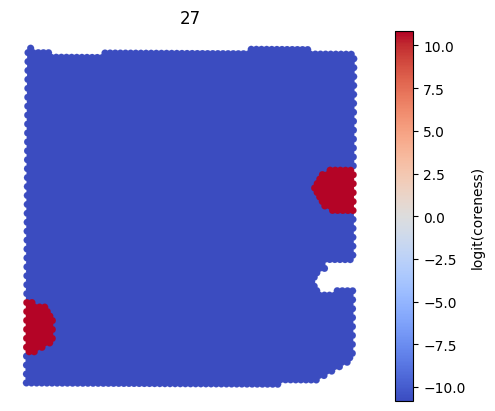

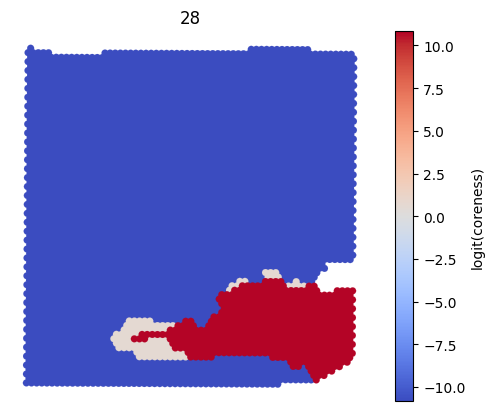

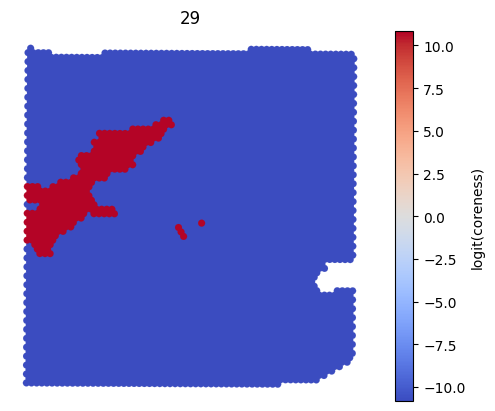

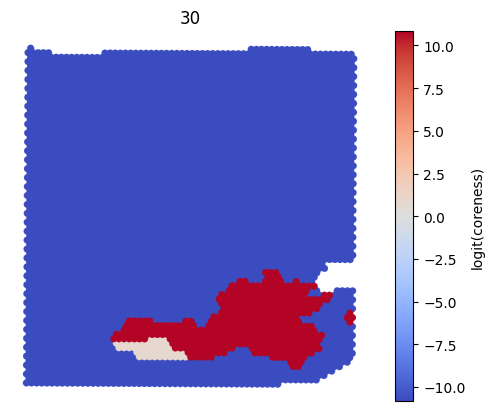

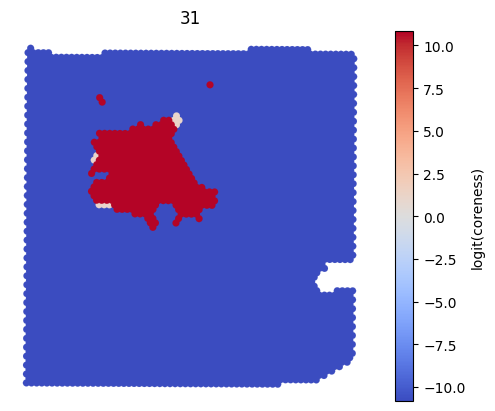

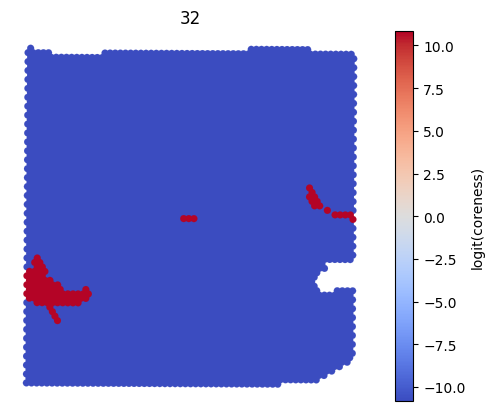

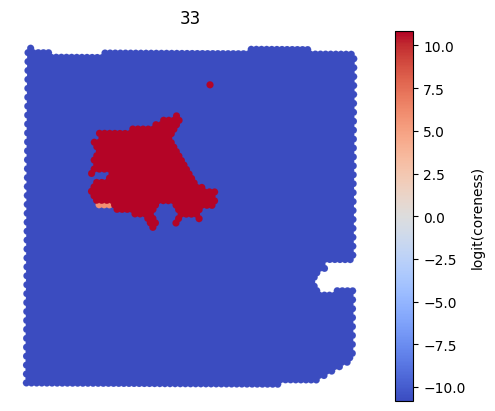

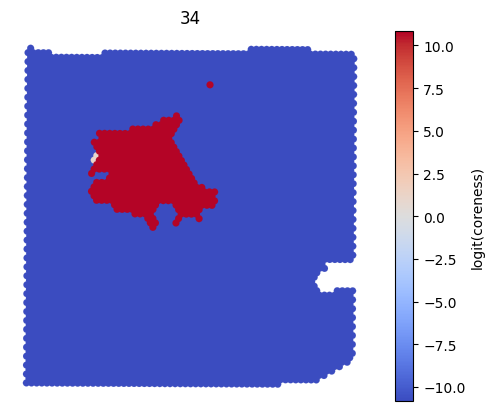

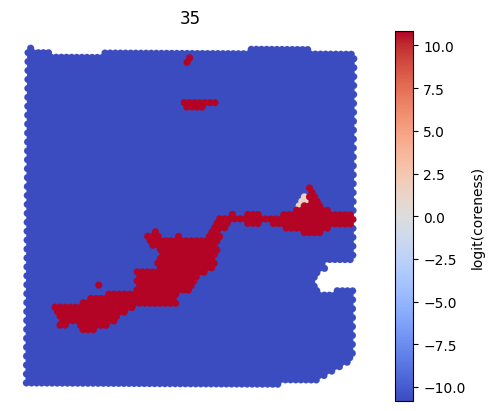

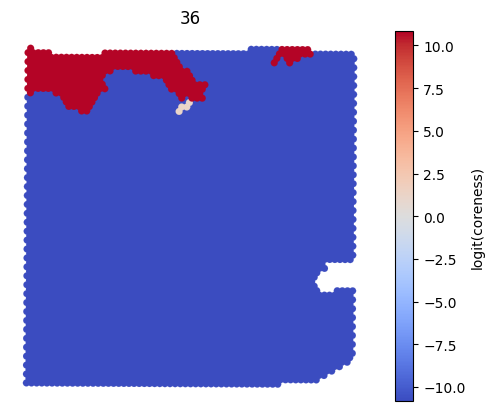

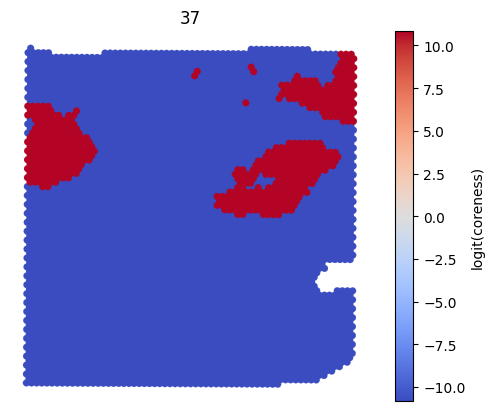

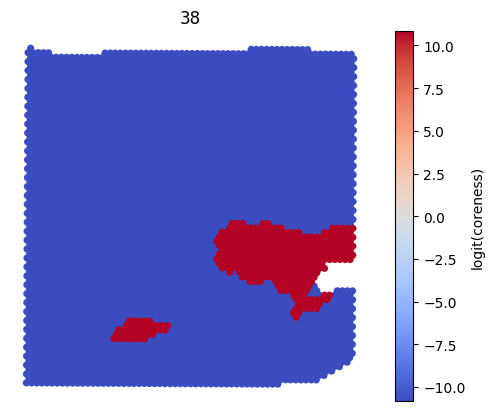

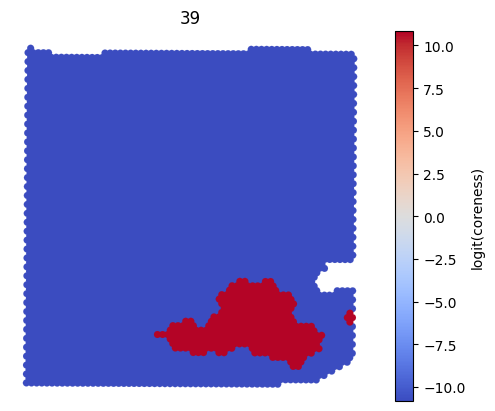

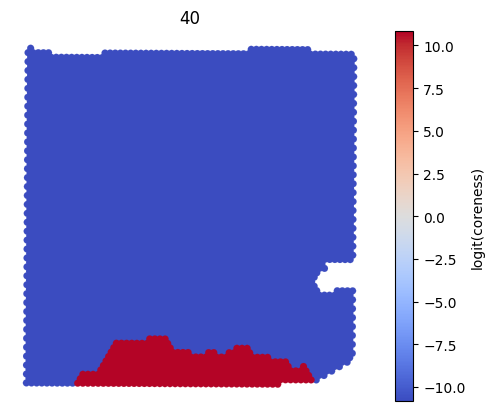

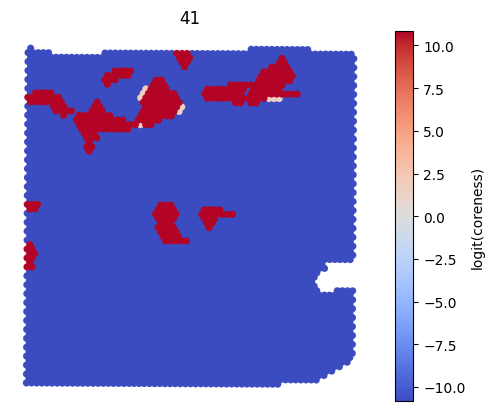

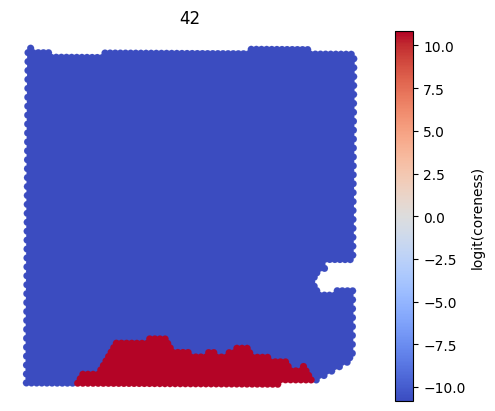

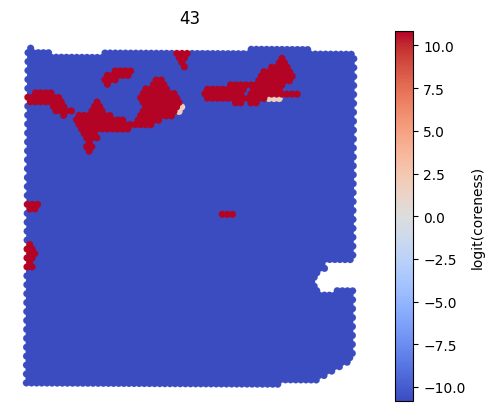

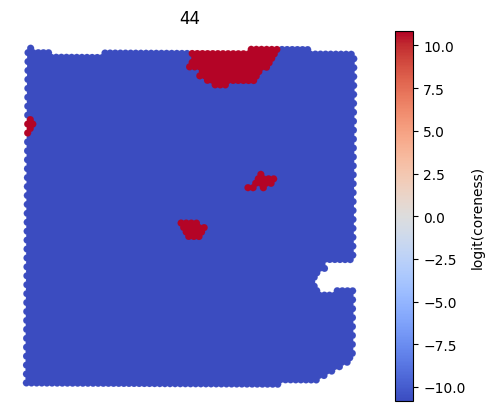

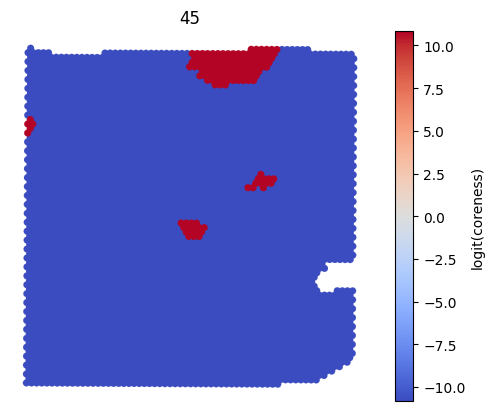

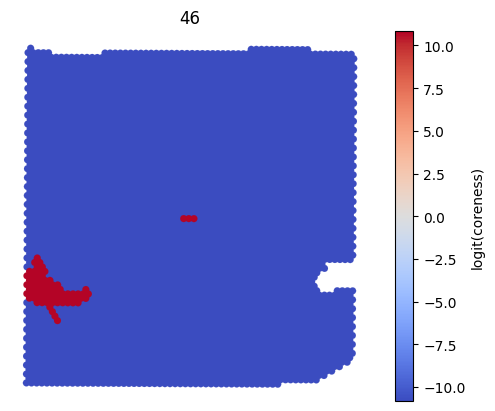

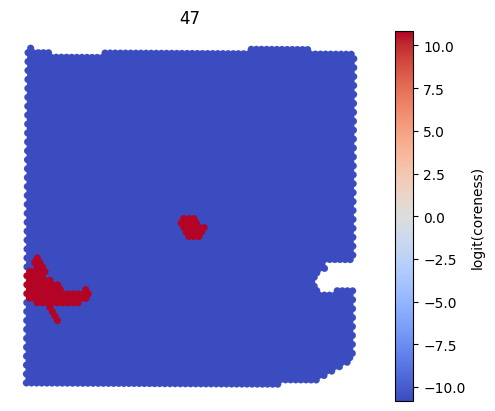

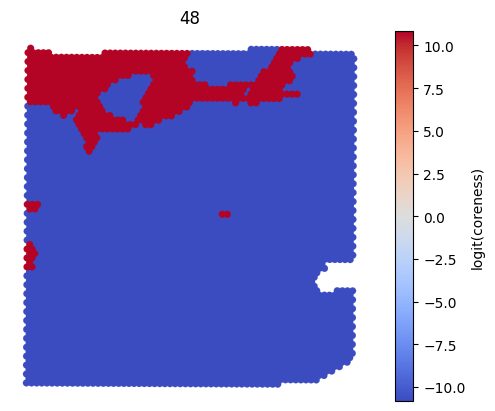

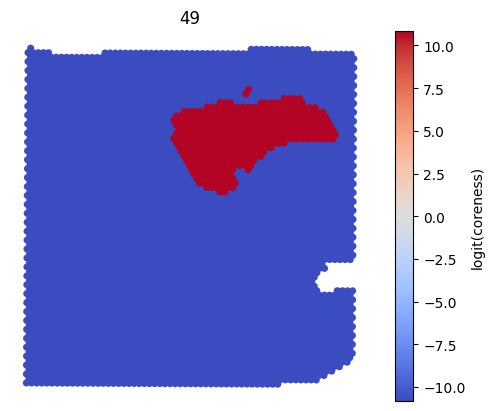

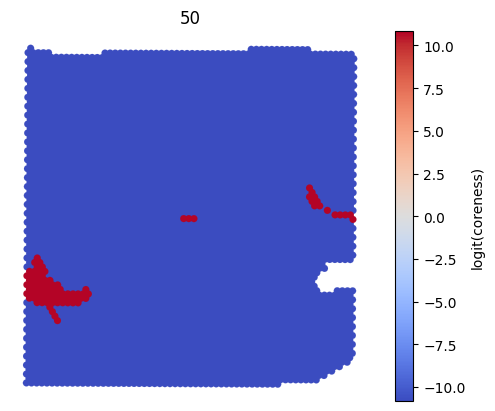

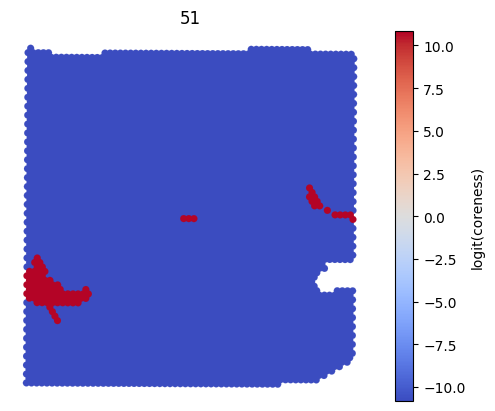

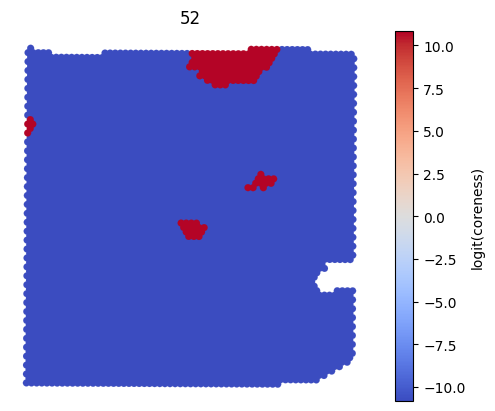

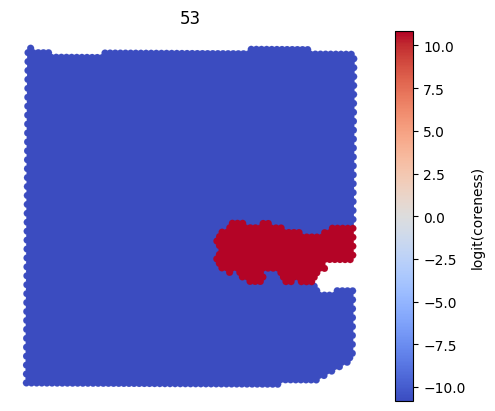

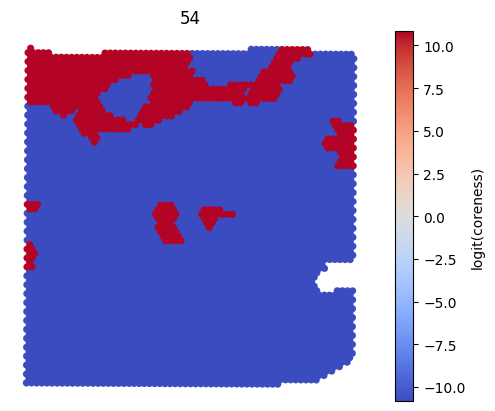

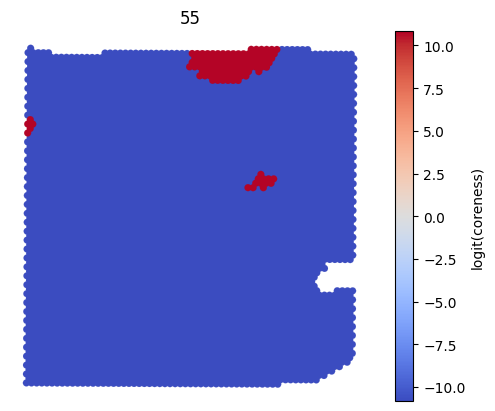

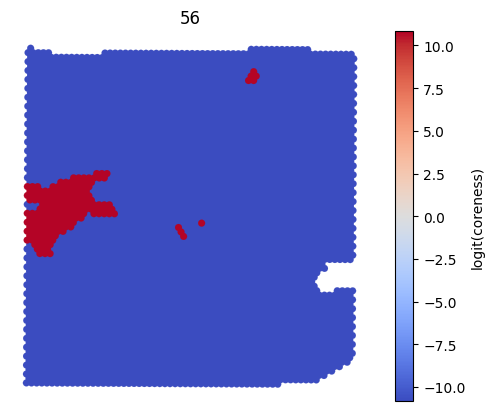

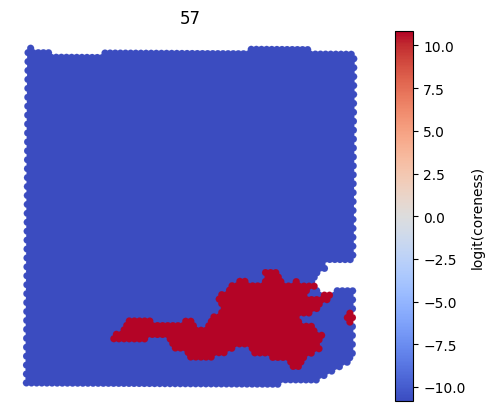

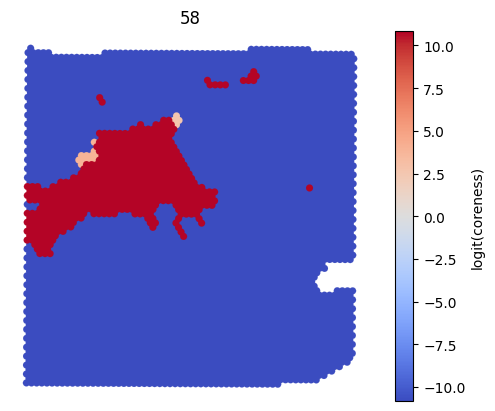

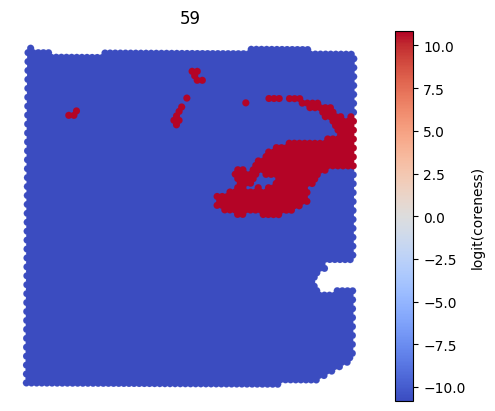

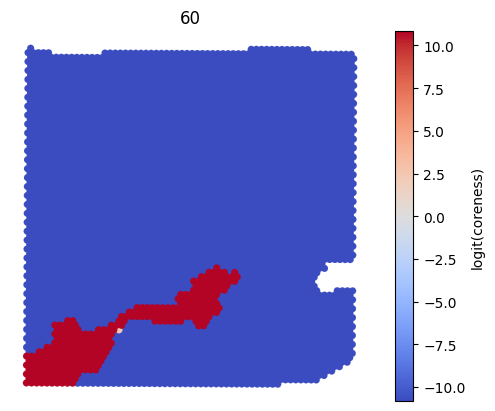

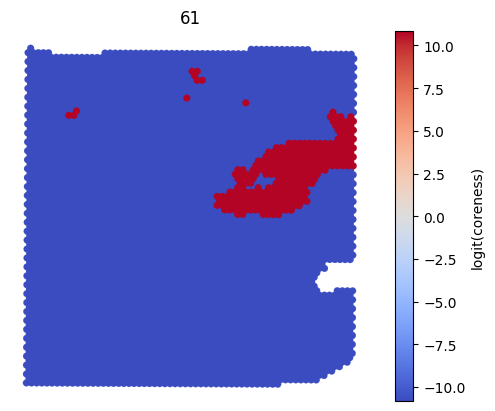

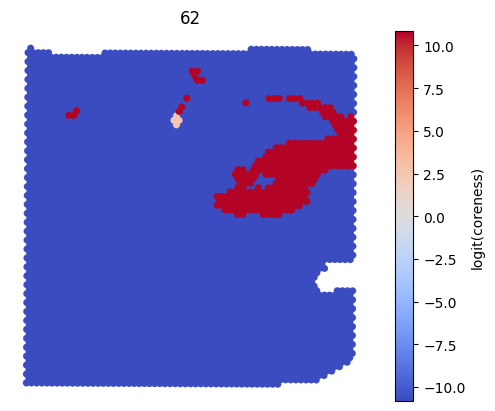

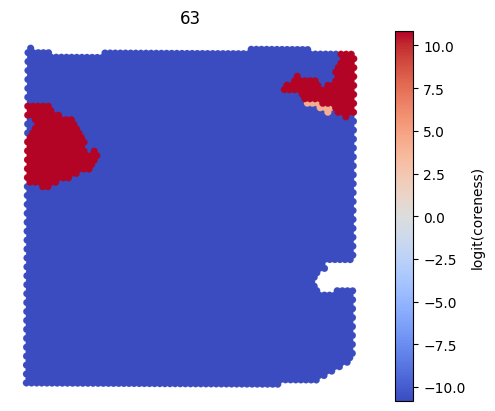

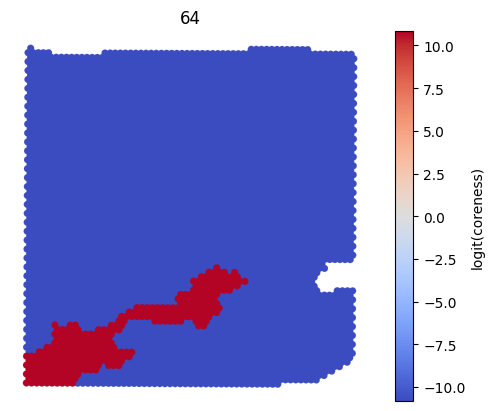

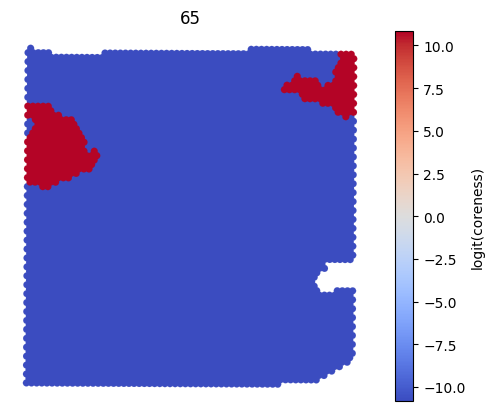

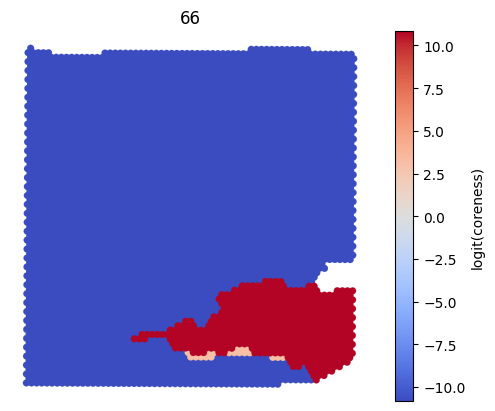

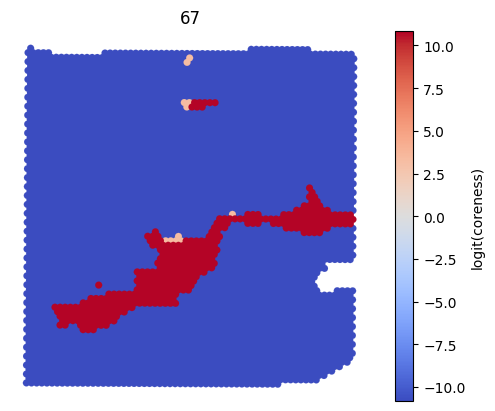

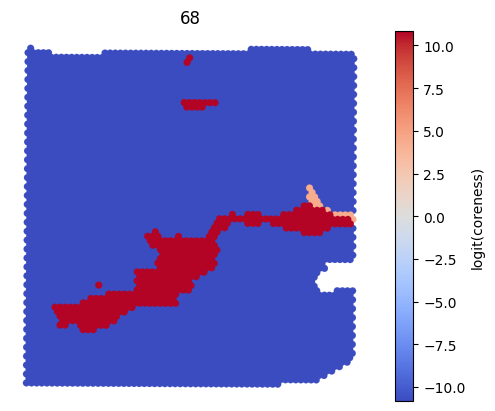

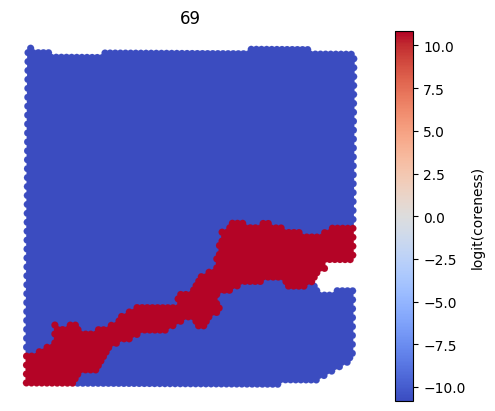

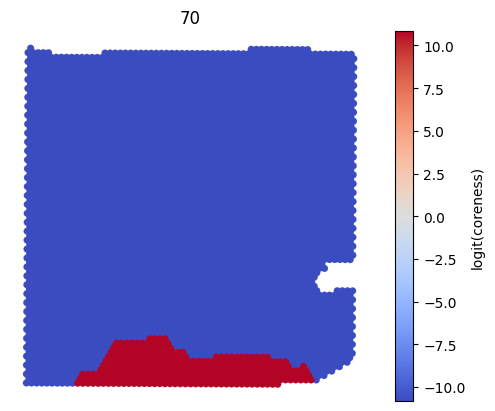

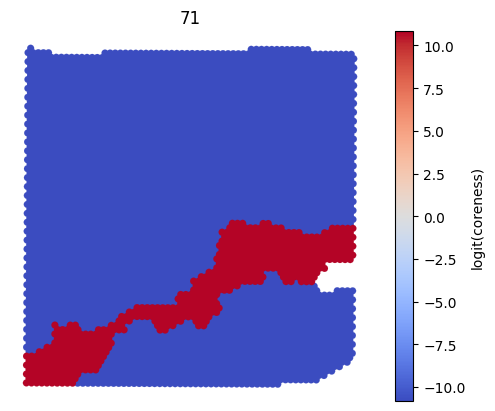

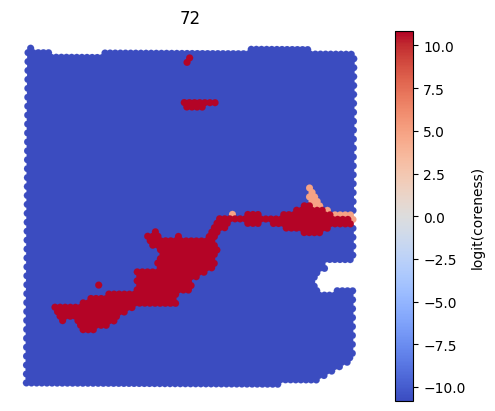

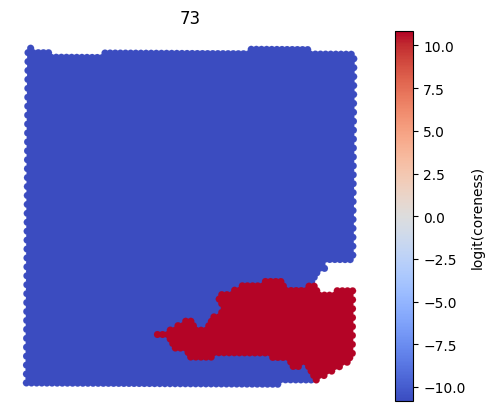

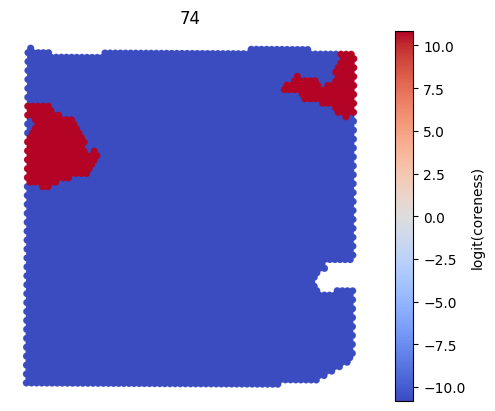

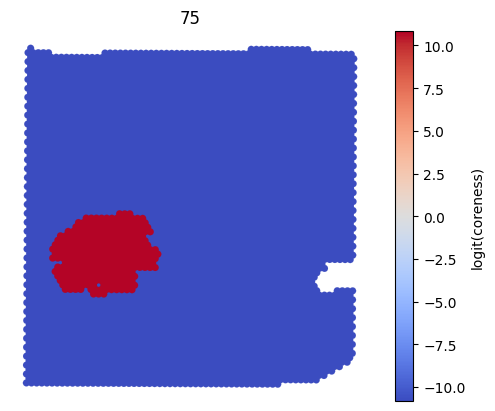

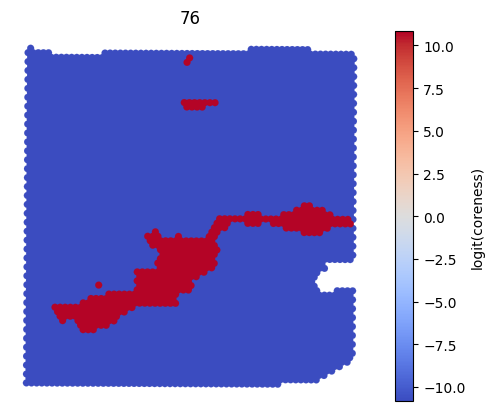

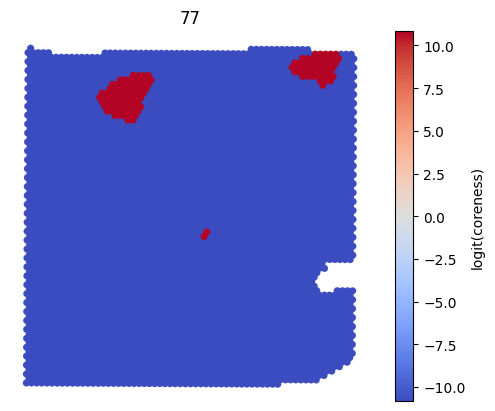

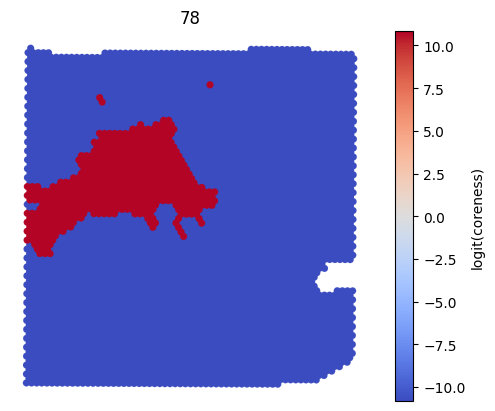

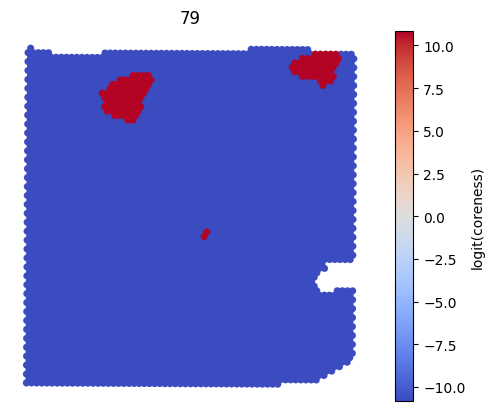

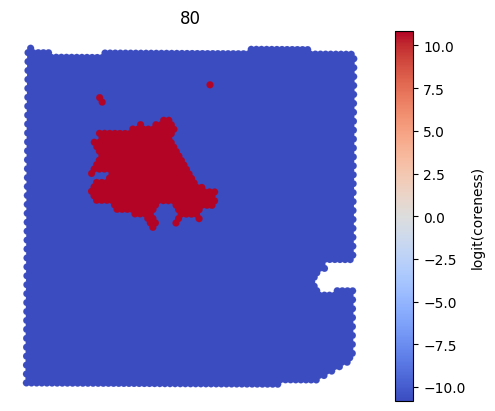

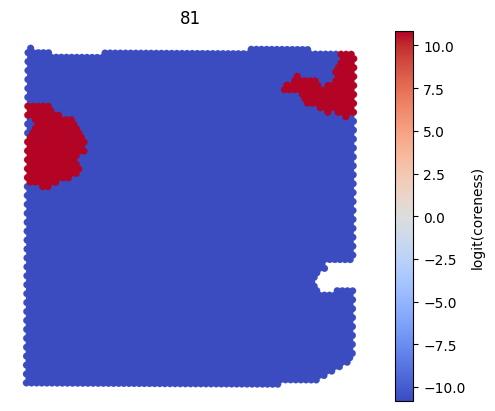

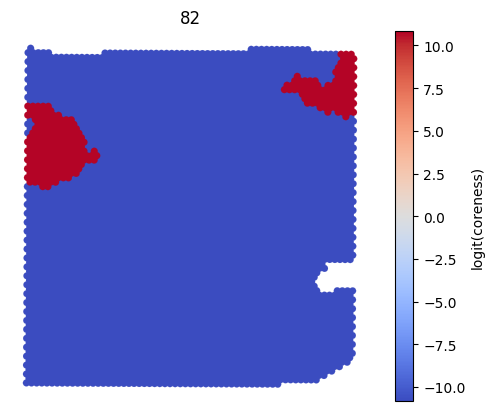

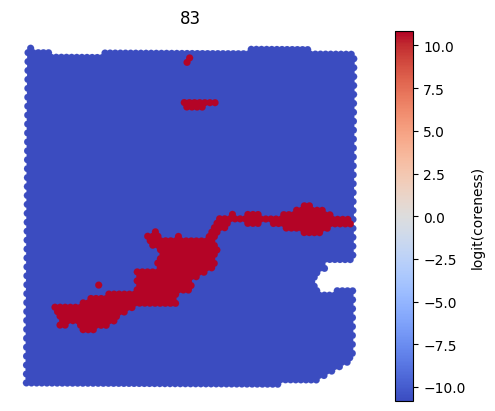

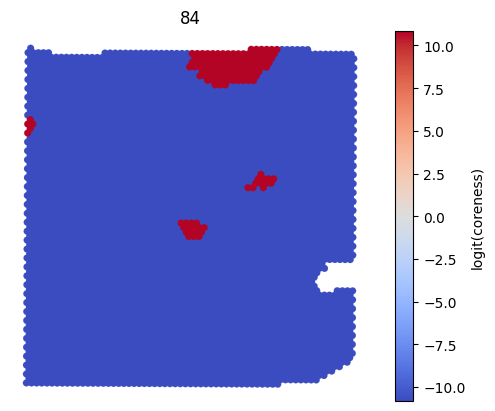

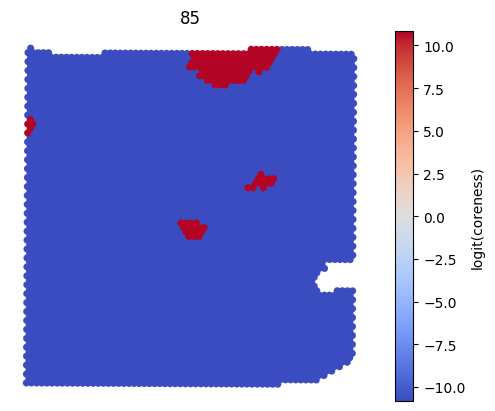

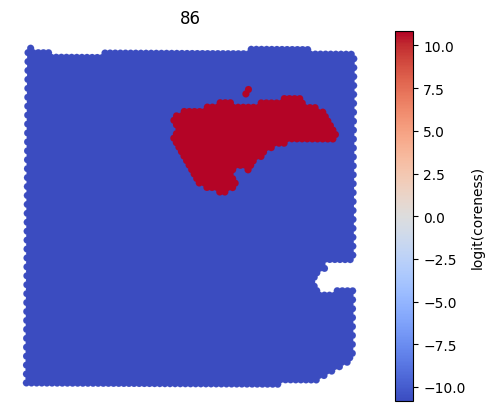

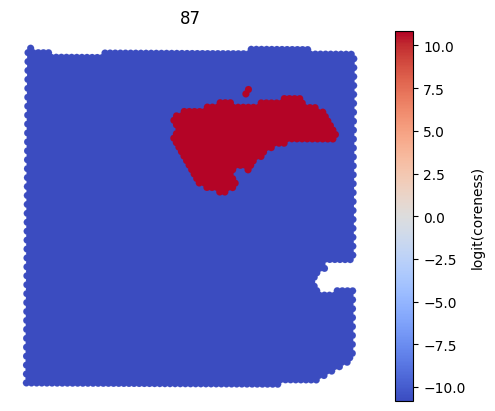

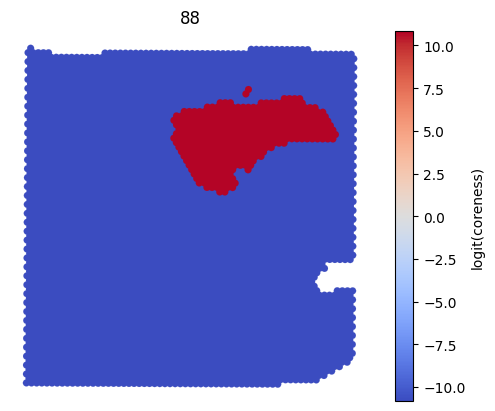

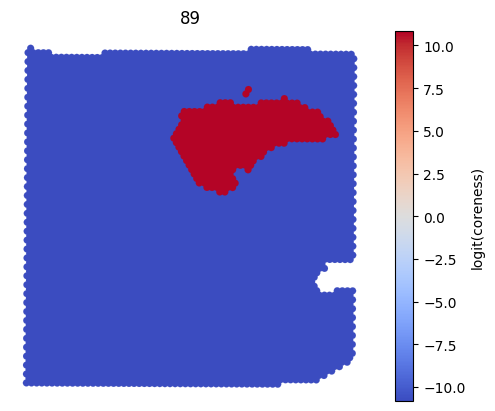

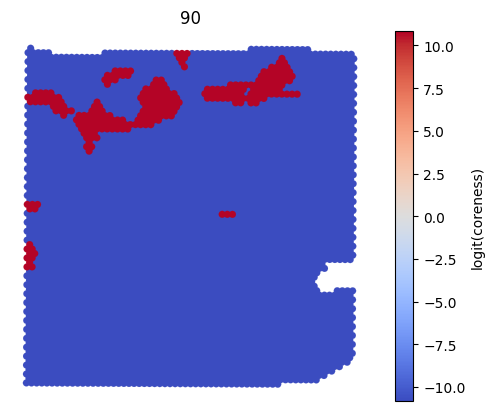

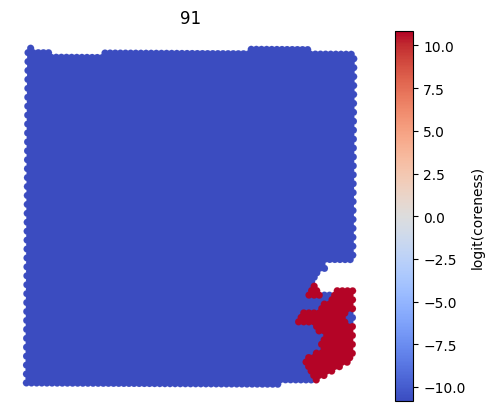

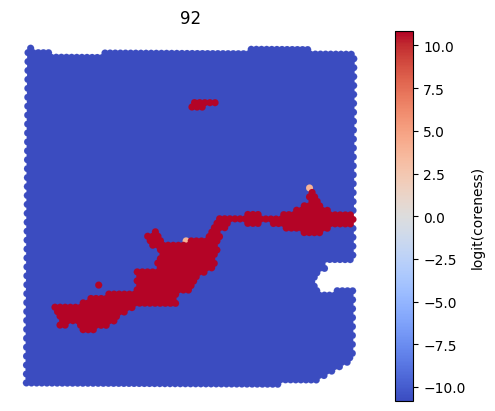

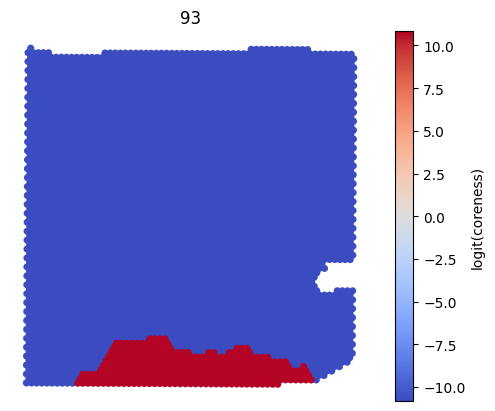

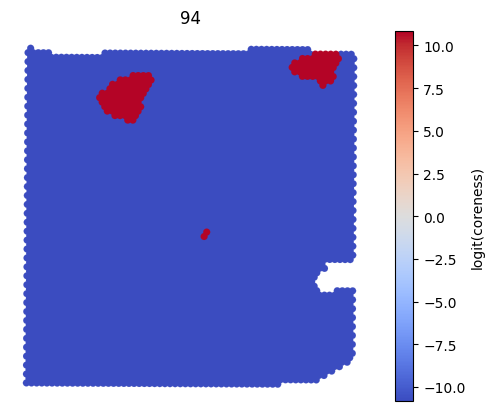

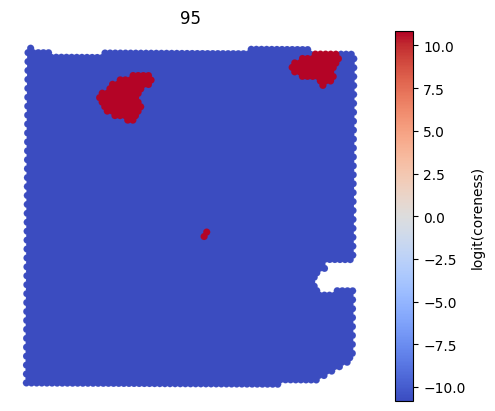

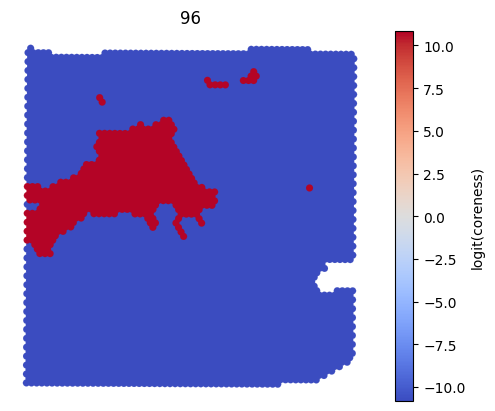

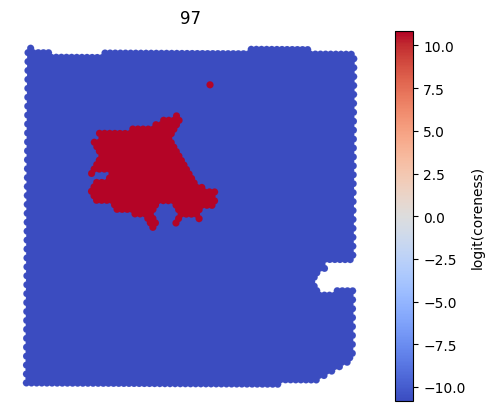

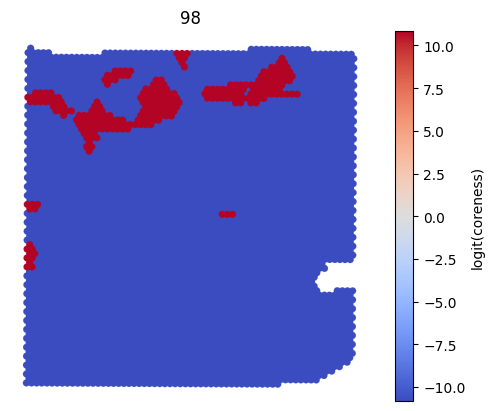

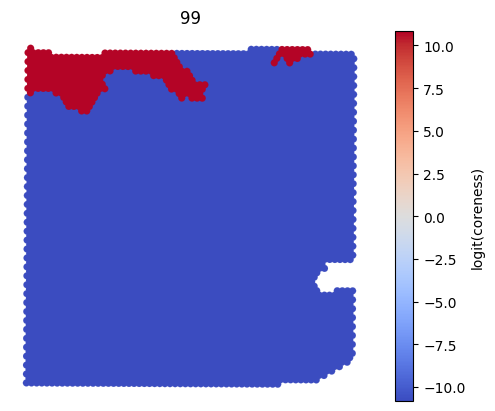

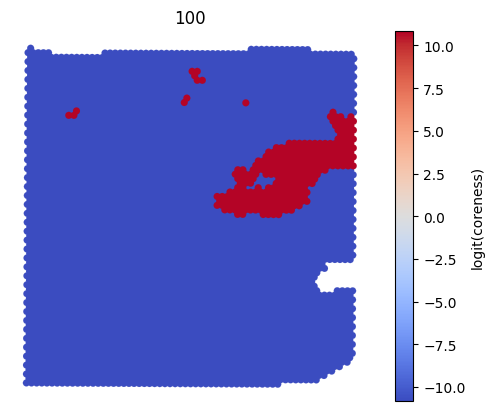

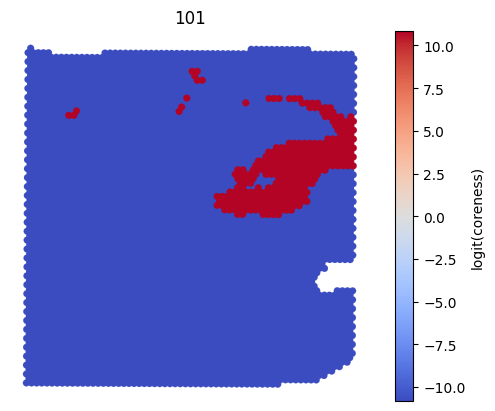

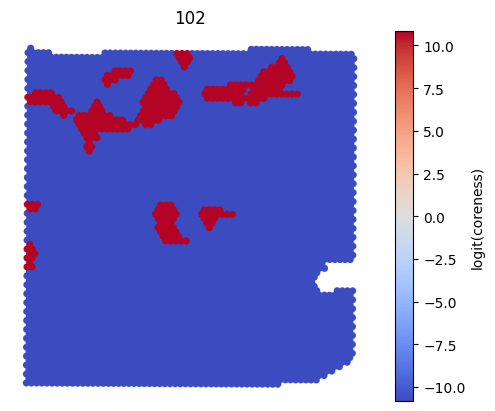

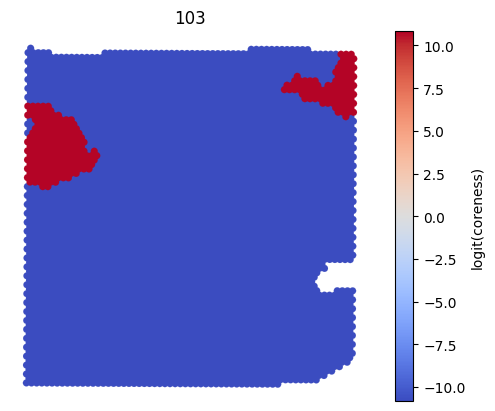

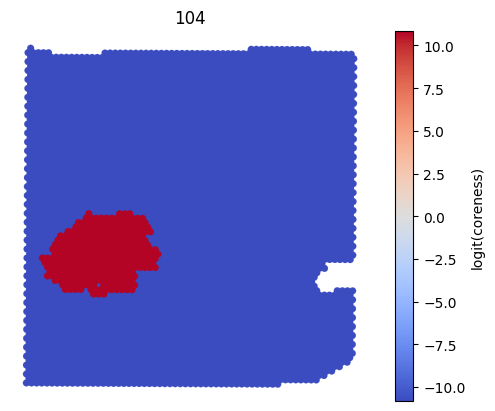

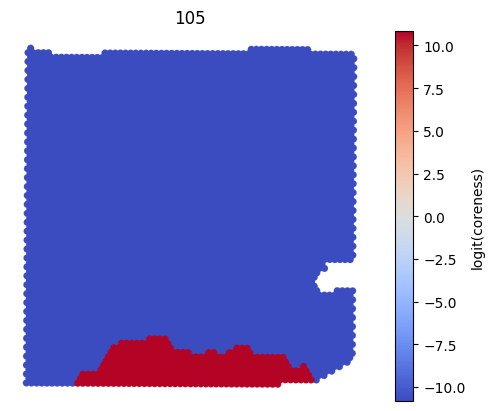

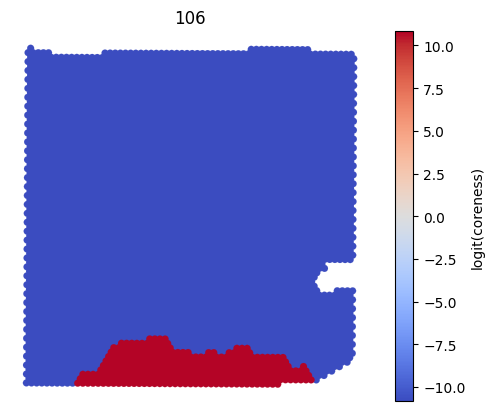

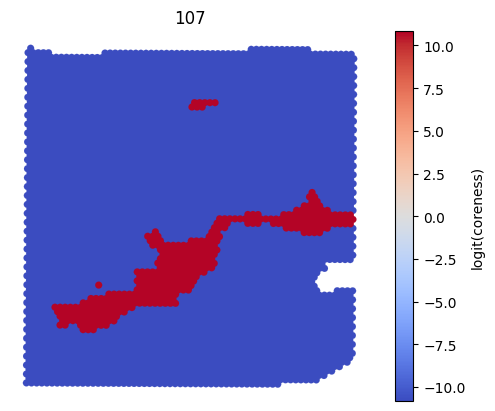

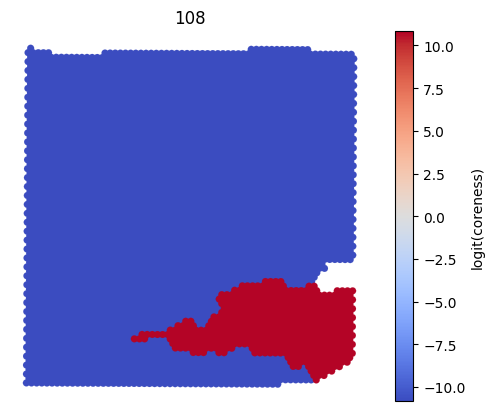

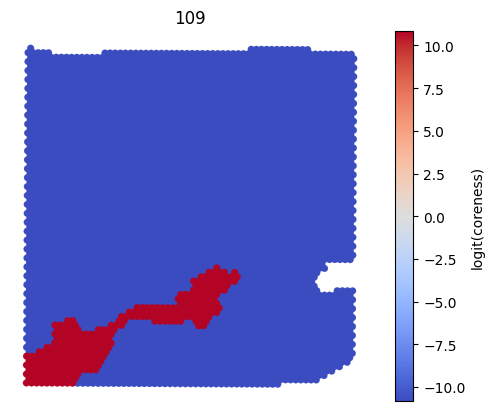

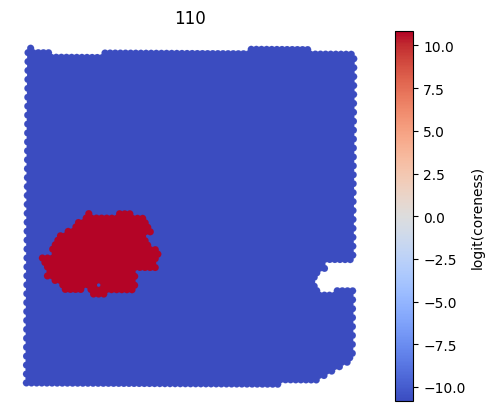

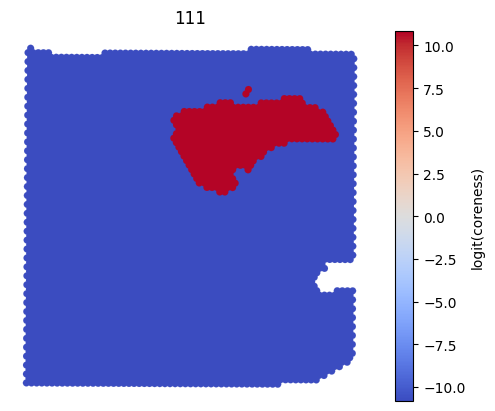

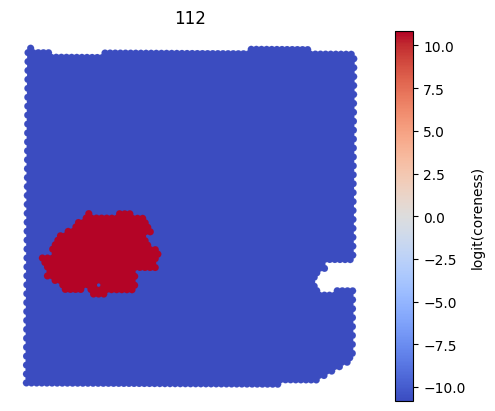

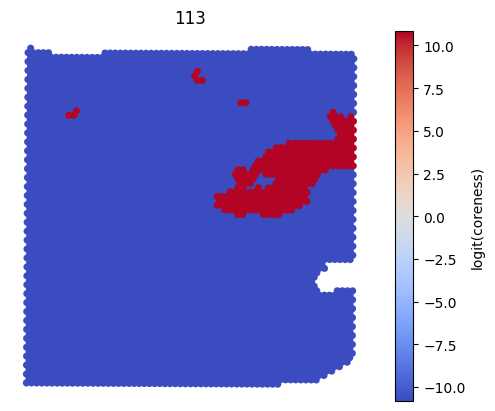

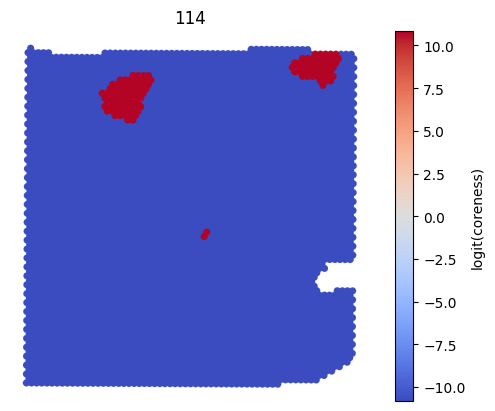

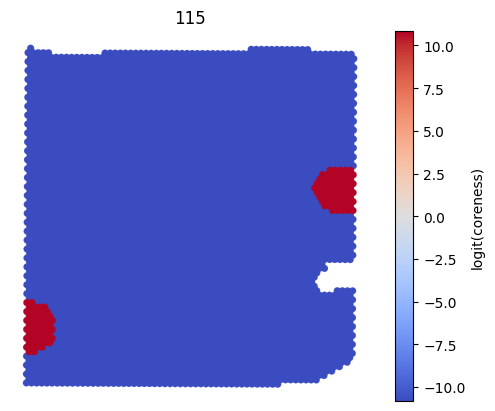

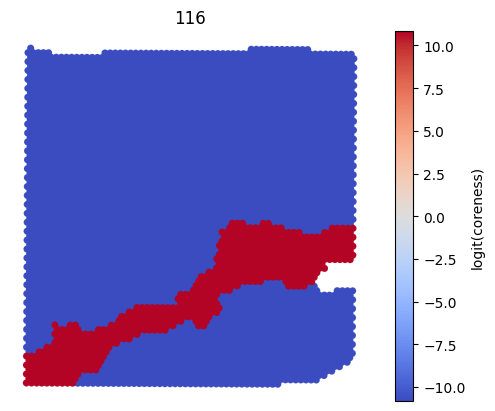

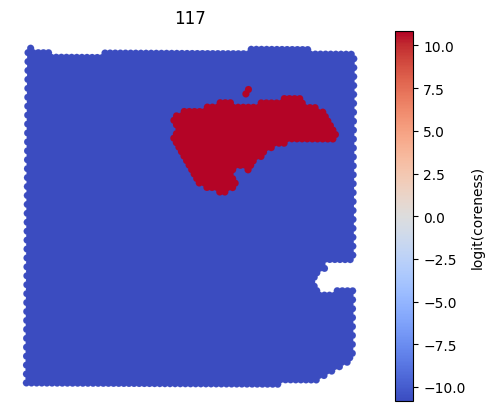

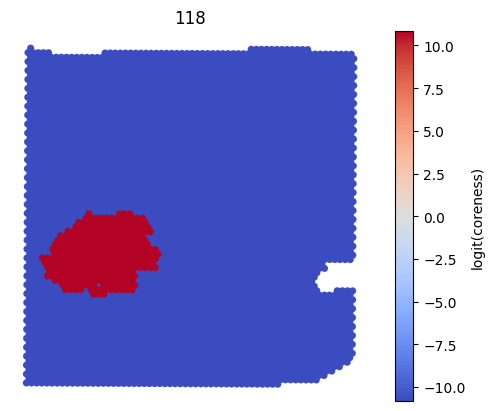

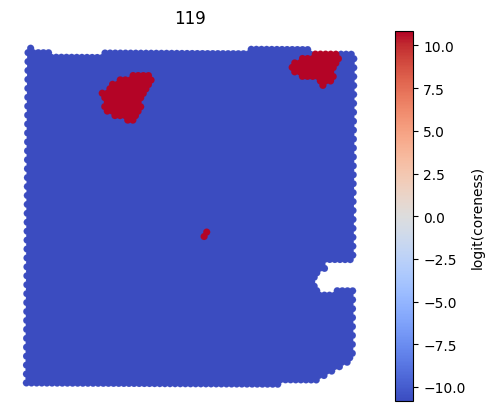

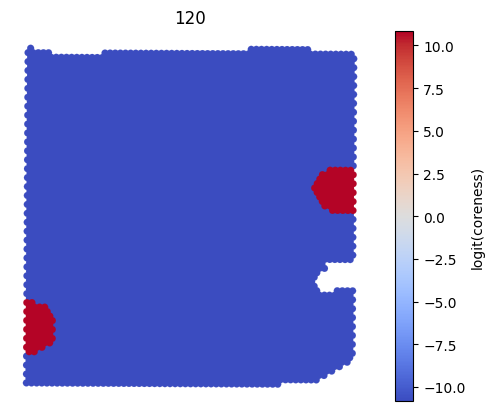

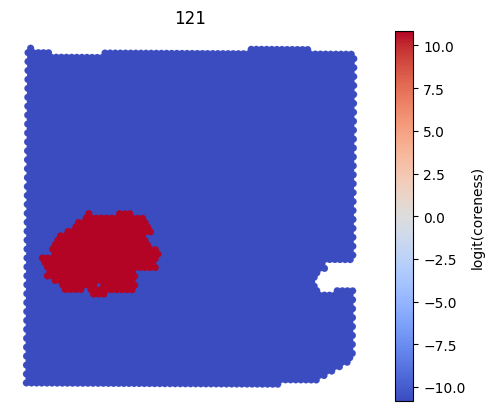

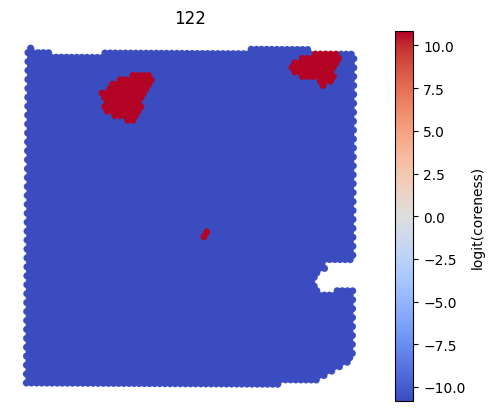

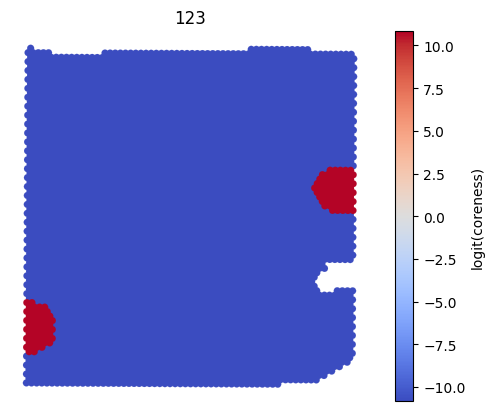

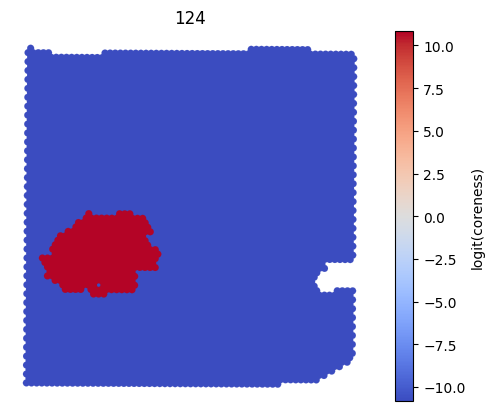

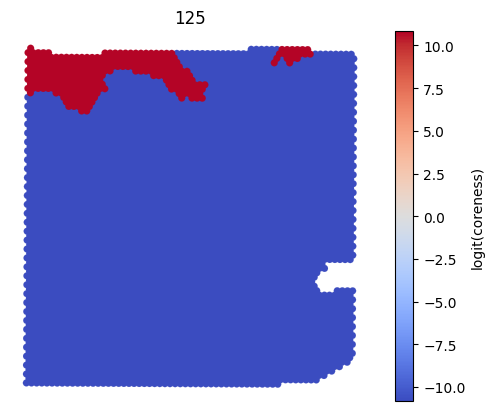

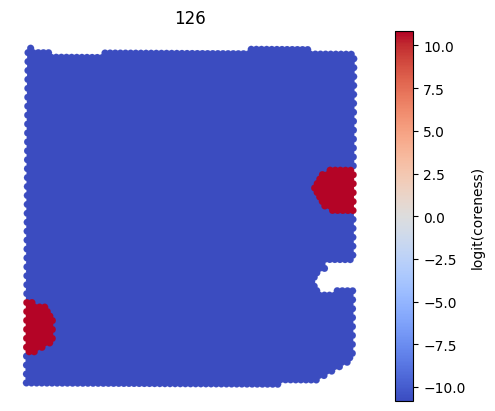

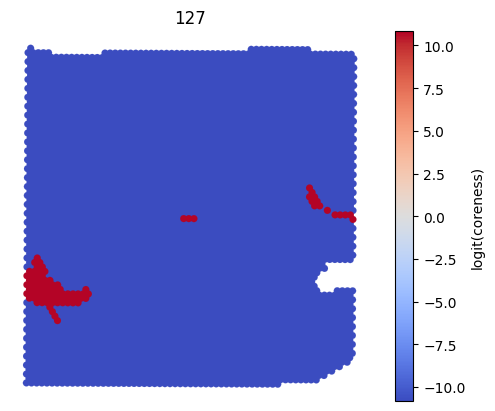

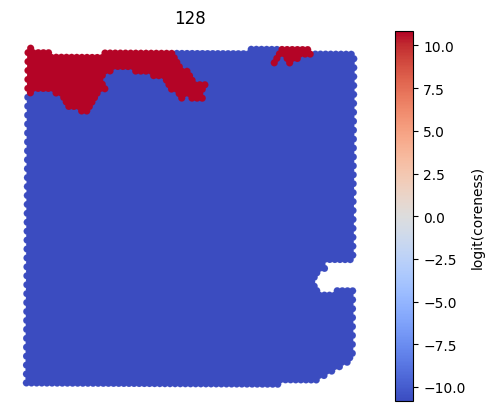

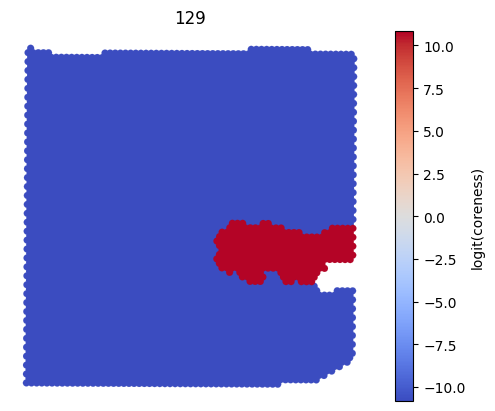

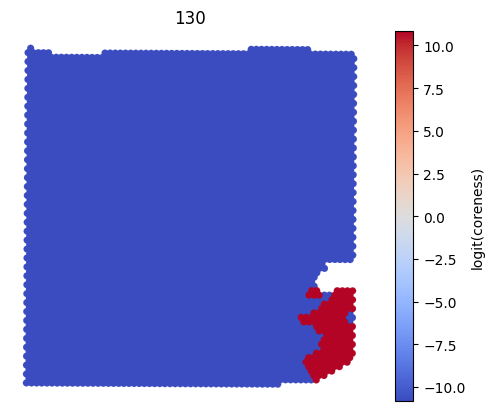

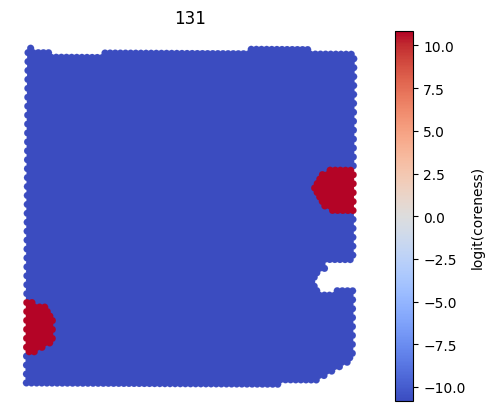

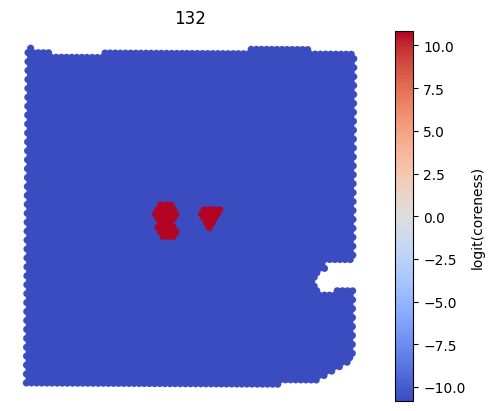

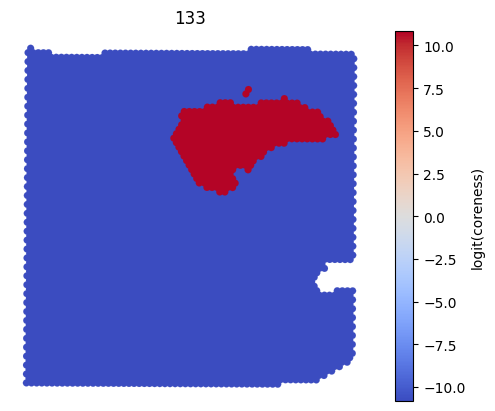

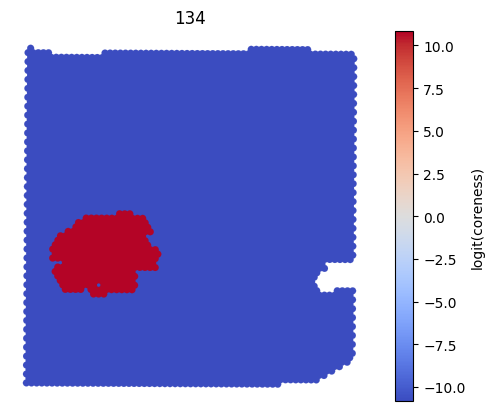

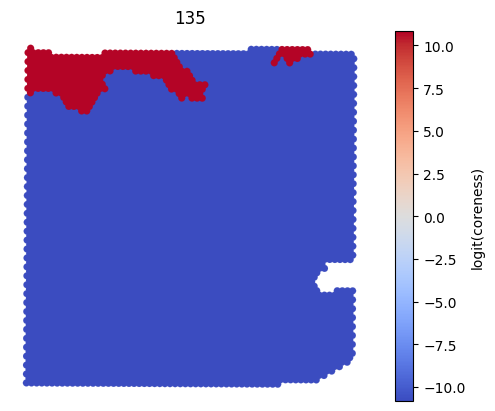

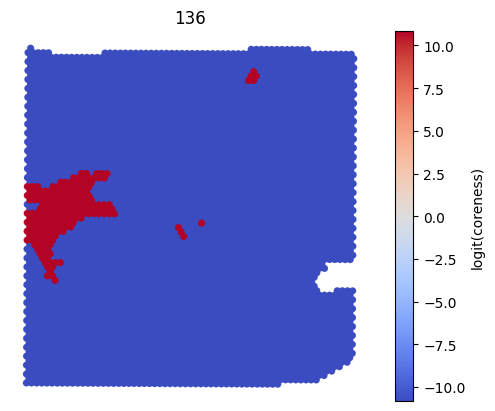

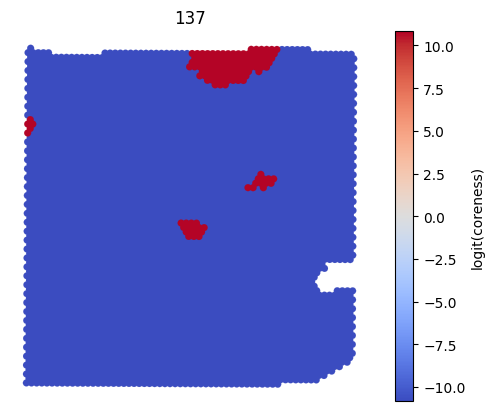

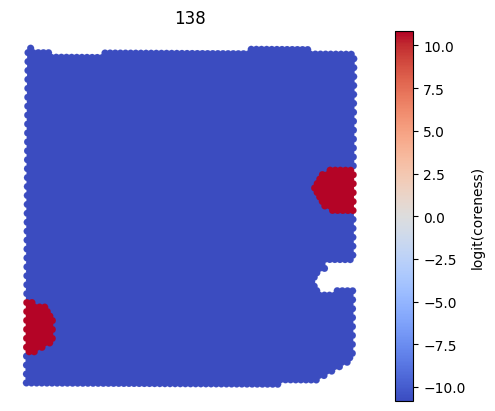

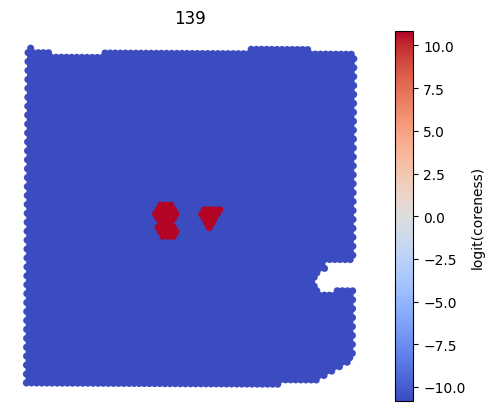

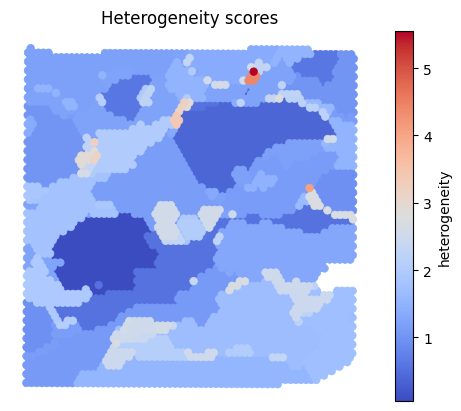

In [5]:

#Generate multiscale domains
phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='persistence',plots='on');
adata.obsm['multiscale'] = phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=10,filt=0,order='persistence',plots='off')